In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
print("1. Loading California Housing Dataset...")
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame

# Inspect first few rows and check missing values
print("\n--- Dataset Preview ---")
print(df.head())

print("\n--- Checking Missing Values ---")
print(f"Total Missing Values: {df.isnull().sum().sum()}")

1. Loading California Housing Dataset...

--- Dataset Preview ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- Checking Missing Values ---
Total Missing Values: 0


In [5]:
print("\n2. Splitting into Features (X) and Target Variable (y)...")
X = housing_data.data
y = housing_data.target  # Median house value in $100,000s


2. Splitting into Features (X) and Target Variable (y)...


In [6]:
print("3. Splitting into Training (80%) and Testing (20%) Sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

3. Splitting into Training (80%) and Testing (20%) Sets...


In [7]:
print("   Applying StandardScaler to features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


   Applying StandardScaler to features...


In [8]:
print("4 & 5. Training Multiple Linear Regression Model (OLS)...")
model = LinearRegression()
model.fit(X_train_scaled, y_train)

4 & 5. Training Multiple Linear Regression Model (OLS)...


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
print("6. Predicting Target Values on Test Set...")
y_pred = model.predict(X_test_scaled)

6. Predicting Target Values on Test Set...


In [10]:
print("7. Calculating Evaluation Metrics...")
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

7. Calculating Evaluation Metrics...


In [11]:
# Display feature weights / coefficients
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Weight)': model.coef_
}).sort_values(by='Coefficient (Weight)', ascending=False)

print("\n--- Model Coefficients ---")
print(coefficients_df.to_string(index=False))
print(f"\nModel Intercept (b0): {model.intercept_:.4f}")

# Display metrics
print("\n--- Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Mean Squared Error (MSE)       : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R-squared Score (R2)           : {r2:.4f}")


--- Model Coefficients ---
   Feature  Coefficient (Weight)
    MedInc              0.854383
 AveBedrms              0.339259
  HouseAge              0.122546
Population             -0.002308
  AveOccup             -0.040829
  AveRooms             -0.294410
 Longitude             -0.869842
  Latitude             -0.896929

Model Intercept (b0): 2.0719

--- Evaluation Metrics ---
Mean Absolute Error (MAE)      : 0.5332
Mean Squared Error (MSE)       : 0.5559
Root Mean Squared Error (RMSE) : 0.7456
R-squared Score (R2)           : 0.5758


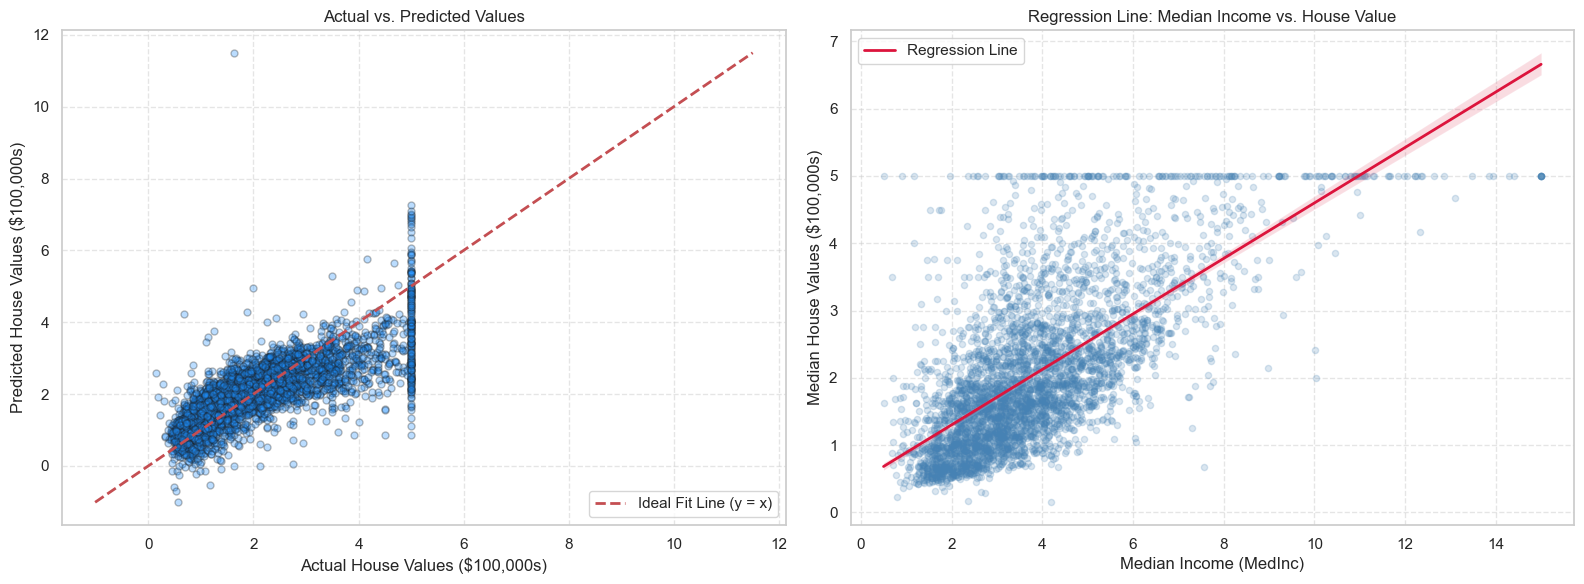

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs. Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='dodgerblue', edgecolors='k', s=25)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit Line (y = x)')
axes[0].set_xlabel('Actual House Values ($100,000s)')
axes[0].set_ylabel('Predicted House Values ($100,000s)')
axes[0].set_title('Actual vs. Predicted Values')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Regression Line for Median Income (MedInc)
sns.regplot(
    x=X_test['MedInc'], 
    y=y_test, 
    ax=axes[1],
    scatter_kws={'alpha': 0.2, 'color': 'steelblue', 's': 20}, 
    line_kws={'color': 'crimson', 'linewidth': 2, 'label': 'Regression Line'}
)
axes[1].set_xlabel('Median Income (MedInc)')
axes[1].set_ylabel('Median House Values ($100,000s)')
axes[1].set_title('Regression Line: Median Income vs. House Value')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()